In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

CSV_PATH = 'train.csv'   # adjust if running from a different cwd
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows — columns: {list(df.columns)}')
df.head()

Loaded 13,759 rows — columns: ['text', 'label', 'char_len', 'word_count']


,text,label,char_len,word_count
0,lehké ovladani,1,14,2
1,realisticke,1,11,1
2,grafika krasna,1,14,2
3,lehce se prehreje konzole protoze edice 24 nen...,0,72,11
4,rychlé a intuitivní nastavení,1,29,4


In [2]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Null values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate texts:', df['text'].duplicated().sum())
df = df.dropna(subset=['text'])

Shape: (13759, 4)

Dtypes:
text            str
label         int64
char_len      int64
word_count    int64
dtype: object

Null values:
text          0
label         0
char_len      0
word_count    0
dtype: int64

Duplicate rows: 0
Duplicate texts: 0


              count  pct (%)
Negative (0)   3696     26.9
Positive (1)  10063     73.1


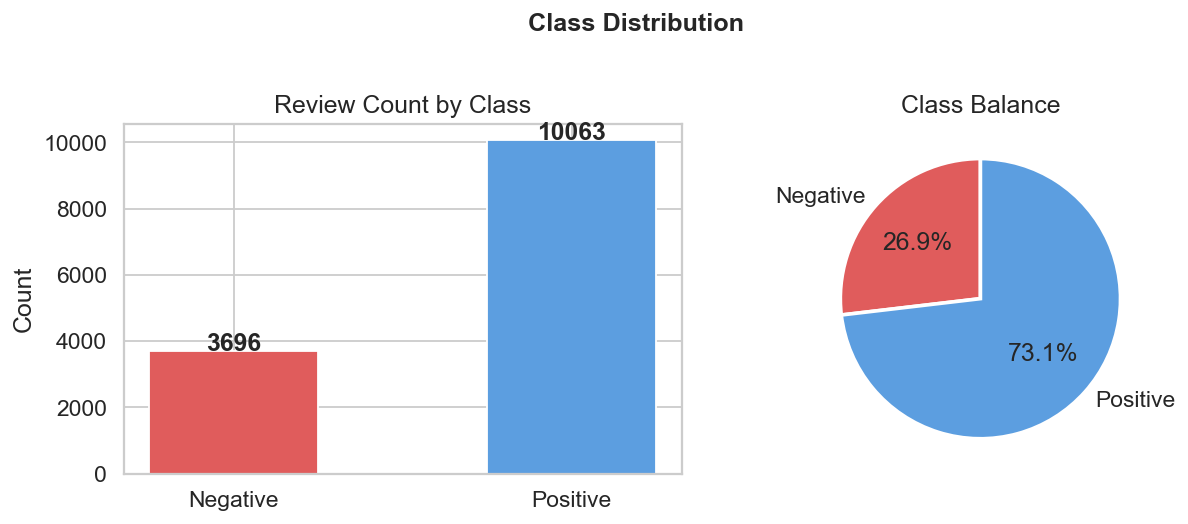


Imbalance ratio (pos:neg) = 2.72:1


In [3]:
counts = df['label'].value_counts().sort_index()
pct    = df['label'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'count': counts, 'pct (%)': pct.round(1)})
summary.index = ['Negative (0)', 'Positive (1)']
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar
colors = ['#e05c5c', '#5c9ee0']
axes[0].bar(['Negative', 'Positive'], counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Review Count by Class')
axes[0].set_ylabel('Count')

# pie
axes[1].pie(counts.values, labels=['Negative', 'Positive'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance')

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\nImbalance ratio (pos:neg) = {counts[1]/counts[0]:.2f}:1')